# **UNAD**
## **Fabián Andres Peña Gonzalez**
### **Agrupamiento en K-means**

**Pasos de la Actividad**

1. Realizar un análisis exploratorio de los datos para identificar relaciones entre variables, valores atípicos, tendencias, etc.
2. Preprocesar los datos limpiándolos, tratando valores faltantes y transformándolos según sea necesario
3. Seleccionar las características más relevantes para entrenar el modelo utilizando selección de características
4. Entrenar el modelo configurando los diferentes hiperparámetros
5. Evaluar el desempeño del modelo con métricas como Coeficiente de Silhouette, Índice de Calinski-Harabasz, etc
6. Realizar las diferentes gráficas que permitan visualizar los resultados del modelo.
7. Interpretar, analizar y documentar los resultados obtenido.s
8. Crear una cuenta en GitHub y cargar los códigos de los modelos diseñados https://github.com/

### **1. Realizar un análisis exploratorio de los datos para identificar relaciones entre variables, valores atípicos, tendencias, etc.** 

In [ ]:
#Cargar las librerias necesarias

import pandas as pd # Manejo y análisis de estructuras de datos
import numpy as np # Cálculo numérico y el análisis de datos
import seaborn as sns # Creación gráficos estadísticos
import matplotlib.pyplot as plt # Creación de gráficos en dos dimensiones
import plotly.graph_objs as go # Creación de gráficos en tres dimensiones
import plotly.express as px # Creación de gráficos en tres dimensiones

# librerías de para implementar modelo Kmeans
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

# librerías de para evaluar el modelo
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

#Librería para evitar la advertencia de que el modelo de KMeans tiene una pérdida de memoria en Windows 
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# lectura de datos en Python y lo cargamos en la variable Datos

Datos = pd.read_csv('C:/Unad/Mall_Customers.csv')

In [170]:
# Realizamos lectura de los Datos para el análisis exploratorio

Datos.head(40)

,Age,Annual Income (k$),Spending Score (1-100),Grupo
0,19,15,39,2
1,21,15,81,5
2,20,16,6,2
3,23,16,77,5
4,31,17,40,2
5,22,17,76,5
6,35,18,6,2
7,23,18,94,5
8,64,19,3,2
9,30,19,72,5


In [172]:
# Descripción de los datos
Datos.describe()

,Age,Annual Income (k$),Spending Score (1-100),Grupo
count,200.000000,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000,2.260000
std,13.969007,26.264721,25.823522,1.728391
min,18.000000,15.000000,1.000000,0.000000
25%,28.750000,41.500000,34.750000,1.000000
50%,36.000000,61.500000,50.000000,2.000000
75%,49.000000,78.000000,73.000000,4.000000
max,70.000000,137.000000,99.000000,5.000000


Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

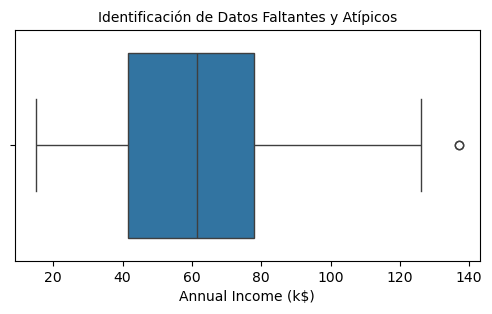

In [174]:
#Identificación de Datos Faltantes y Atípicos

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['Annual Income (k$)'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

### **2. Preprocesar los datos limpiándolos, tratando valores faltantes y transformándolos según sea necesario**


In [176]:
#Revisión de datos faltantes

print("Cantidad de Registros con cero en Edad: ",Datos['Age'].isin([0]).sum())
print("Cantidad de Registros con cero en Ingresos anuales: ",Datos['Annual Income (k$)'].isin([0]).sum())
print("Cantidad de Registros con cero en Puntuación de gastos: ",Datos['Spending Score (1-100)'].isin([0]).sum())

Cantidad de Registros con cero en Edad:  0
Cantidad de Registros con cero en Ingresos anuales:  0
Cantidad de Registros con cero en Puntuación de gastos:  0


Text(0.5, 1.0, 'Identificación de Datos Atípicos')

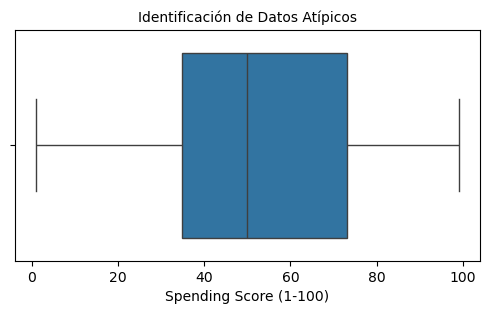

In [178]:
#Identificación de Datos Atípicos

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['Spending Score (1-100)'])
plt.title('Identificación de Datos Atípicos', fontsize=10 )

In [180]:
#Conteo de Datos Atípicos

nivel_minimo=0
nivel_maximo=100
Total_Atipicos=((Datos['Spending Score (1-100)']<nivel_minimo)|(Datos['Spending Score (1-100)']>nivel_maximo)).sum()
print("El total de datos atípicos es {}".format(Total_Atipicos))


El total de datos atípicos es 0


In [182]:
# Filtra Datos Atípicos

Datos=Datos[(Datos['Spending Score (1-100)']<nivel_maximo)&(Datos['Spending Score (1-100)']>nivel_minimo)]


In [184]:
#Revisión del tipo de datos y datos faltantes

Datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     200 non-null    int64
 1   Annual Income (k$)      200 non-null    int64
 2   Spending Score (1-100)  200 non-null    int64
 3   Grupo                   200 non-null    int32
dtypes: int32(1), int64(3)
memory usage: 5.6 KB


### **3. Seleccionar las características más relevantes para entrenar el modelo utilizando selección de características**


Características de interes para el agrupamiento:


- Ingresos anuales


- Puntuacion de gasto


- Edad

In [186]:
# Filtrar columnas del modelo 

Datos = Datos[["Age","Annual Income (k$)","Spending Score (1-100)"]]

In [188]:

# Revisión de los datos de las variables objetivo

Datos.head(10)

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
5,22,17,76
6,35,18,6
7,23,18,94
8,64,19,3
9,30,19,72


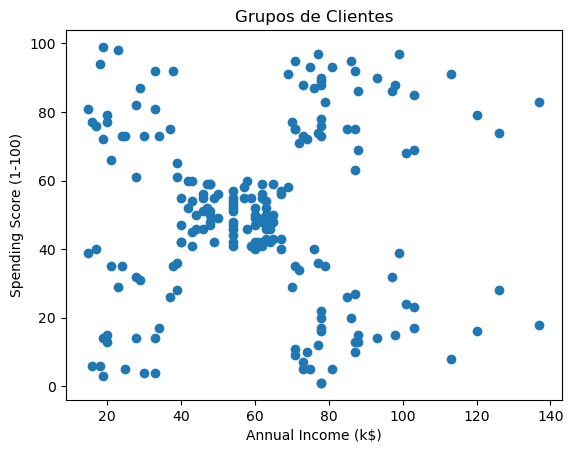

In [190]:
# Grafica antes del agrupamiento

plt.scatter(Datos['Annual Income (k$)'], Datos['Spending Score (1-100)'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Grupos de Clientes')
plt.show()

### **4. Entrenar el modelo configurando los diferentes hiperparámetros**

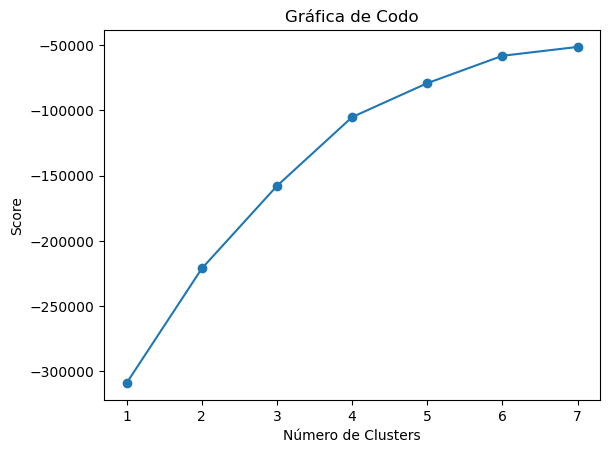

In [192]:
#Se realiza gráfica de codo para identificar valor de K

Nc = range(1, 8)
kmeans = [KMeans(n_clusters=i) for i in Nc]
kmeans
score = [kmeans[i].fit(Datos).score(Datos) for i in range(len(kmeans))]
score
plt.plot(Nc,score, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Score')
plt.title('Gráfica de Codo')
plt.show()

In [194]:
# Generación del modelo de Agrupamiento del modelo con K=5 (Es decir haremos 5 grupos de agrupamiento) 

Modelo = KMeans(n_clusters=6, random_state=0)
Modelo.fit(Datos)

KMeans(n_clusters=6, random_state=0)

In [196]:
#Se agrega la columna Grupo a la BD para identificar el numero de grupo del agrupamiento

Modelo.labels_
Datos["Grupo"] = Modelo.labels_ 
print (Datos)

     Age  Annual Income (k$)  Spending Score (1-100)  Grupo
0     19                  15                      39      2
1     21                  15                      81      5
2     20                  16                       6      2
3     23                  16                      77      5
4     31                  17                      40      2
..   ...                 ...                     ...    ...
195   35                 120                      79      1
196   45                 126                      28      3
197   32                 126                      74      1
198   32                 137                      18      3
199   30                 137                      83      1

[200 rows x 4 columns]


### **5. Evaluar el desempeño del modelo con métricas como Coeficiente de Silhouette, Índice de Calinski-Harabasz, etc**

In [198]:
# Desempeño del modelo con el Coeficiente de Silhouette el Índice de Calinski-Harabasz y el índice de Davies Bouldin Score

# Preparación de la metrica de la columna Grupo
Observaciones = len(Datos)
X = Datos.drop('Grupo', axis=1)
clusters = Datos['Grupo']

# Se calculan las métricas
sil_score = silhouette_score(X, clusters)
calinski_score = calinski_harabasz_score(X, clusters)
davies_score = davies_bouldin_score(X, clusters)

# Se crea una tabla para mostrar los valores de las métricas
table_data = [
    ["Numero de Observaciones", Observaciones],
    ["Coeficiente Silhouette", sil_score],
    ["Indice Calinski Harabasz", calinski_score],
    ["Indice Davies Bouldin", davies_score]
]

# Imprime la tabla
from tabulate import tabulate
print(tabulate(table_data, headers=["Metric", "Value"], tablefmt='pretty'))

+--------------------------+---------------------+
|          Metric          |        Value        |
+--------------------------+---------------------+
| Numero de Observaciones  |         200         |
|  Coeficiente Silhouette  | 0.45095124469943243 |
| Indice Calinski Harabasz |  166.5857109469557  |
|  Indice Davies Bouldin   | 0.7515325100425706  |
+--------------------------+---------------------+


### **6. Realizar las diferentes gráficas que permitan visualizar los resultados del modelo**

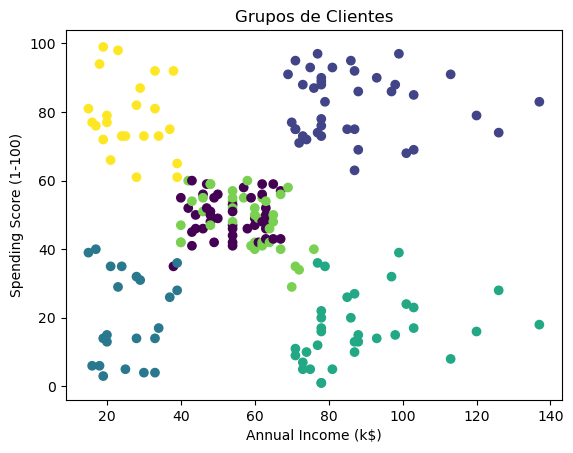

In [200]:
plt.scatter(Datos['Annual Income (k$)'], Datos['Spending Score (1-100)'], c=Datos['Grupo'], cmap='viridis')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Grupos de Clientes')
plt.show()


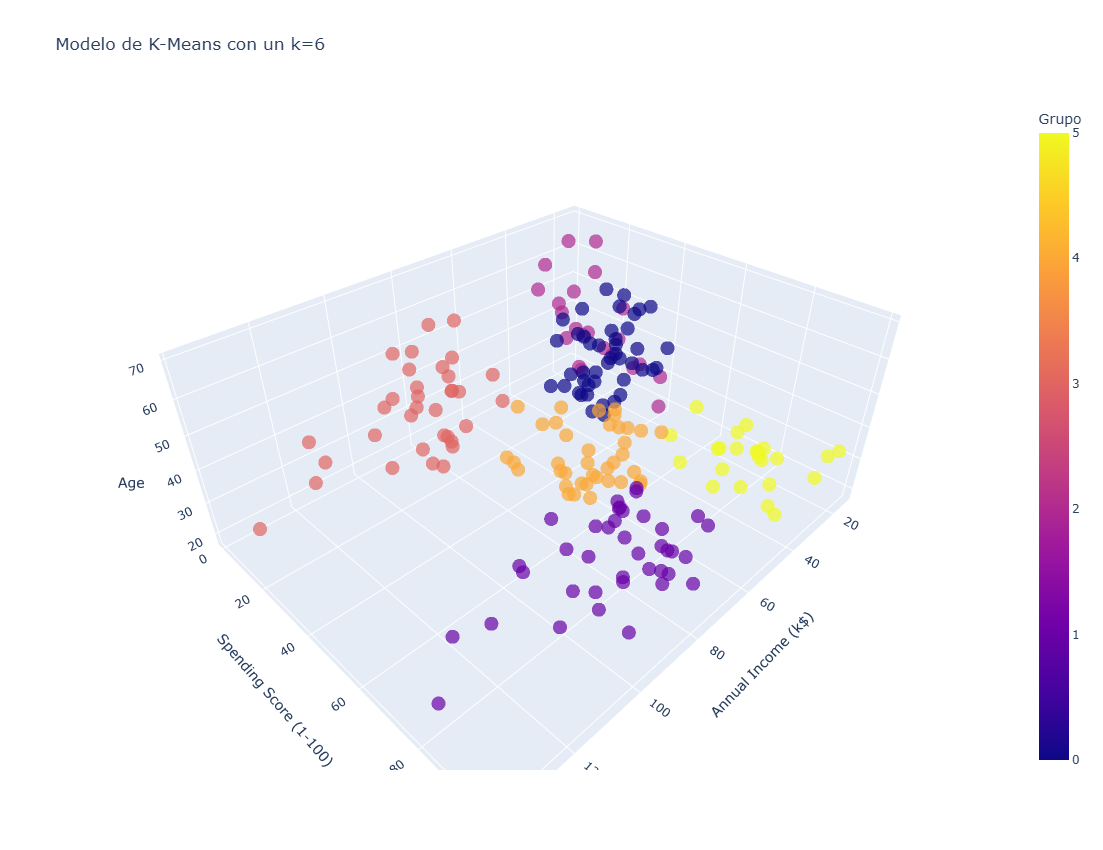

In [166]:
# Crear un modelo 3D de los datos agrupados

Grafica_3D = px.scatter_3d(Datos, x='Annual Income (k$)', y='Spending Score (1-100)', z='Age', color='Grupo', symbol='Grupo', symbol_map={0: 'circle', 1: 'circle', 2: 'circle', 3: 'circle', 4: 'circle', 5: 'circle', 6: 'circle'}, opacity=0.7, width=900, height=850, title=f'Modelo de K-Means con un k={6}', labels={'label': 'Cluster'}, color_discrete_map={})
Grafica_3D.update_layout(showlegend=False) 

### **7. Interpretar, analizar y documentar los resultados obtenidos**

Trabajamos con 3 variables, las cuales son: edad, ingresos anuales (k$), y puntuación de gasto (1-100).

El modelo presento un mejor desempeño trabajando con 6 cluster, que es lo mismo que decir que se crearon 6 grupos.

En el grupo 0, podemos observar que tenemos las personas con una edad mayor, una puntuación de gasto promedio y unos ingresos promedio.

En el grupo 1, tenemos personas con una edad promedio, puntajes de gasto alto e ingresos altos.

En el grupo 2, la edad es variada, se caracteriza por puntajes de gasto bajos e ingresos bajos.

En el grupo 3, la edad tambien es variada, puntajes de gasto bajos y a diferencias del grupo anterior tienen unos ingresos altos.

En el grupo 4, las personas son jovenes, tienen un puntaje de gasto promedio e ingresos promedio.

Y por ultimo el grupo 5, las personas son tambien jovenes, poseen un puntaje de gasto alto y sus ingresos son bajos.
